**computing distances:**
- kmeans relies on distances to compute cluster membership: by computing the distances between centroids and all points and then assigning points to the centroid with which they've got the smallest distance
- new centroids are then computed by avveraging all points in a particular cluster: clusters are determined by which centroid u belong to...this continues till convergence or after n_iterations

computing the euclidean distance....

In [7]:
import math
import numpy as np

def dist(a,b):
    return math.sqrt(math.pow(a[0] - b[0], 2) + \
                    math.pow(a[1] - b[1], 2))

above method is naive becuase it performs element-wise calculations on the data (slow) compared to more real-world implementation using vectors and matrices and broadcasting to achieve this

In [8]:
centroids = [(2,5), (8,3), (4,5)]
x = (0, 8)

In [9]:
centroid_distances = []

for centroid in centroids:
    print(f"Euclidean distance between x {x} and centroid {centroid} is {dist(x,centroid)}")

Euclidean distance between x (0, 8) and centroid (2, 5) is 3.605551275463989
Euclidean distance between x (0, 8) and centroid (8, 3) is 9.433981132056603
Euclidean distance between x (0, 8) and centroid (4, 5) is 5.0


forming clusters with the notion of distance:

In [10]:
cluster_1_points = [ (0,8), (3,8), (3,4) ]
cluster_1_points = np.array(cluster_1_points)

In [11]:
cluster_1_points.shape

(3, 2)

In [12]:
# mean or the new centroid would then be:
cluster_1_points.mean(axis = 0)

array([2.        , 6.66666667])

after a new centroid is calculated as in above, repeat the cluster membership computation (computing the distance between centroids and all points and cluster assignment based on nearest centroid). Eventually, the new cluster centroid will be the same as the centroid before cluster membership calculation (centroids stop changing - this is convergence) and the exercise will be complete. How many times this repeats depends on the data you're clustering... 

- k-means convergence is achieved once the centroids have stopped changing much...new centroid after a new round of centroid computation is similar to the previous centroid...
- However in practice, sometimes the number of iterations required to reach convergence is very large and such large computations cannot be practically feasible. In such cases, we need to set a minimum limit to the number of iterations. Once this iteration limit is reached, we stop further processing

**K-Means from scratch: Part 1: Data Generation**

In [14]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import math
np.random.seed(0)

In [15]:
# Generate a random dataset to experiment on...X = coordinate points | y = cluster labels...
X, y = make_blobs(n_samples=1500, centers=3, n_features=2, random_state=800)

In [16]:
centroids = [[-6,2], [3,-4], [-5,10]]

/var/folders/_h/yzv4_kzj2yv3z5xh7lks3hpr0000gn/T/ipykernel_1500/2485922959.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:,0], X[:,1], s=50, cmap='tab20b')


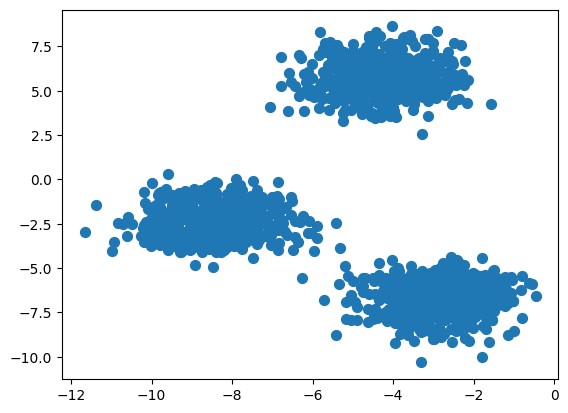

In [17]:
plt.scatter(X[:,0], X[:,1], s=50, cmap='tab20b')
plt.show()

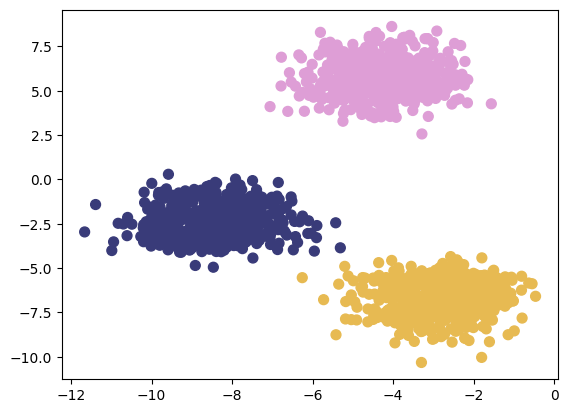

In [18]:
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='tab20b')

In [21]:
from scipy.spatial.distance import cdist, pdist

In [20]:
X[105:110]

array([[-3.09897933,  4.79407445],
       [-3.37295914, -7.36901393],
       [-3.372895  ,  5.10433846],
       [-5.90267987, -3.28352194],
       [-3.52067739,  7.7841276 ]])

In [27]:
pdist(X[105:110], metric='euclidean'),pdist(X[105:110]).shape

(array([12.16617375,  0.41387625,  8.55033918,  3.01964354, 12.47335239,
         4.80528165, 15.15386151,  8.76105094,  2.68386092, 11.32107778]),
 (10,))

In [29]:
cdist(X[105:110], X[105:110])

array([[ 0.        , 12.16617375,  0.41387625,  8.55033918,  3.01964354],
       [12.16617375,  0.        , 12.47335239,  4.80528165, 15.15386151],
       [ 0.41387625, 12.47335239,  0.        ,  8.76105094,  2.68386092],
       [ 8.55033918,  4.80528165,  8.76105094,  0.        , 11.32107778],
       [ 3.01964354, 15.15386151,  2.68386092, 11.32107778,  0.        ]])

ok, so choosing random matrix: X[105:110].
- next we compute the distances

In [34]:
"""
    Find the distance from each of 5 sampled points to all of the centroids
"""
for x in X[105:110]:
    calcs = cdist(x.reshape([1, -1]), centroids).squeeze()
    print(calcs, "Cluster Membership: ", np.argmin(calcs))

[ 4.02775036 10.70202291  5.54216027] Cluster Membership:  0
[ 9.7303528   7.20866583 17.44505393] Cluster Membership:  1
[ 4.06676751 11.11317999  5.15897011] Cluster Membership:  0
[ 5.28441816  8.93146403 13.31415736] Cluster Membership:  0
[ 6.29310516 13.46792103  2.66429839] Cluster Membership:  2


In [ ]:
# define the k_means function which will initialize the k-centroids randomly and then repeats this process until the difference between the new/old centroids equals zero....

def k_means(X, K):
    # keep track of history so as to see K-Means in action
    centroids_history = []
    labels_history = []
    # centroids = X[[0, 1008, 902]]
    centroids = np.array([[-6,2], [3,-4], [-5,10]])
    centroids_history.append(centroids)

    while True:
        # euclidean distances are calculated for each point relative to centroids and then np,argmin returns the index location of the minimal distance - which cluster a point is assigned to
        labels = np.argmin(cdist(X, centroids), axis = 1)
        labels_history.append(labels)

        # take the mean of points within clusters to find centroids
        new_centroids = np.array([X[labels==i].mean(axis=0) for i in range(K)])
        centroids_history.append(new_centroids)

        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids

    return centroids, labels, centroids_history, labels_history

centers, labels, centers_hist, labels_hist = k_means(X, 3) 

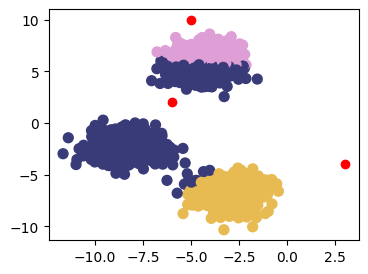

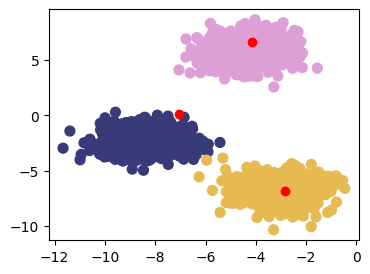

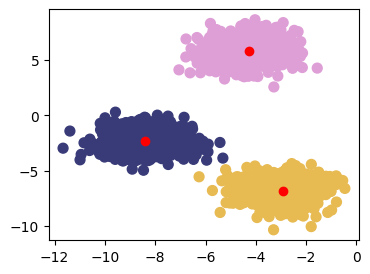

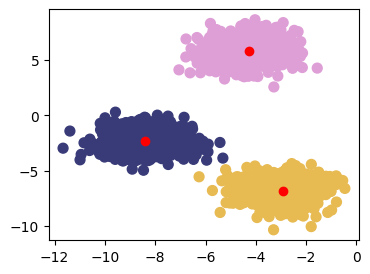

In [44]:
history = zip(centers_hist, labels_hist)
for x, y in history:
    plt.figure(figsize=(4,3))
    plt.scatter(X[:, 0], X[:, 1], c=y,
            s=50, cmap='tab20b');
    plt.scatter(x[:, 0], x[:, 1], c='red')    
    plt.show()

as can be seen by the images above, kmeans takes an iterative approach to refine optimal clusters based on distance. the algorithm starts with random initialization of centroids and, depending on the complexity of the data, quickly finds the separations that make the most sense.

**Clustering Performance: Silhouette Score**
- unfortunately, for clustering, we do not have labels to rely on and we need to build an understanding of how different our clusters are. We achieve this with the silhouette score metric. we can also use the silhouette scores to find the optimal number of clusters
- The silhouette score works by analyzing how well a point fits within a cluster. The metric ranges from -1 to 1. If the average silhouette score across your clustering is one, you will have achieved perfect clusters and there will be minimal confusion about which point belongs where. If the silhouette score is positive, it means that a point is closer to the assigned cluster than it is to neighboring clusters. If the score is 0, then a point lies on the boundary between the assigned cluster and the next closest cluster. if the silhouette score is negative, then it indicates that a given point is assigned to an incorrect cluster and the given point in fact likely belongs to a neighboring cluster.
- Mathematically, silhouette score is computed as ssi_i = b_i - a_i/ max(a_i, b_i). | a_i is the distance between point i and its cluster centroid and b_i is the distance between point i and its nearest cluster centroid.


In [45]:
import pandas as pd
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
np.random.seed(0)

In [46]:
seeds = pd.read_csv('../../data/Seed_Data.csv')

In [47]:
X = seeds[['A','P','C','LK','WK','A_Coef','LKG']]

In [ ]:
np.random.randint

In [102]:
def k_means(X, K):
    # keep track of history so as to see K-Means in action
    centroids_history = []
    labels_history = []
    # centroids = X[[0, 1008, 902]]
    # centroids = np.array([[-6,2,], [3,-4], [-5,10]])
    rng = np.random.default_rng(42)

    centroids = X[rng.choice(len(X), size=3, replace=False)]
    # centroids = np.random.rand(3,7)
    centroids_history.append(centroids)
    n_iters = 25000
    count = 0
    while True:
        # euclidean distances are calculated for each point relative to centroids and then np,argmin returns the index location of the minimal distance - which cluster a point is assigned to
        labels = np.argmin(cdist(X, centroids), axis = 1)
        labels_history.append(labels)

        # take the mean of points within clusters to find centroids
        new_centroids = np.array([X[labels==i].mean(axis=0) for i in range(K)])
        centroids_history.append(new_centroids)

        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids

        count += 1
        if count > n_iters:
            break

    return centroids, labels, centroids_history, labels_history

In [103]:
X_mat.shape

(210, 7)

In [104]:
np.random.normal(size=(3,7)).shape

(3, 7)

In [106]:
X_mat = X.values

centroids, labels, centroids_history, labels_history = k_means(X_mat, 3)

In [107]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2])

In [108]:
# we now compute the silhoette score for area A and length of kernel columns

silhouette_score(X[['A','LK']], labels)

0.5444234976006914